# Diferencijalna jednačina - Masa-opruga-prigušivač sistem

Numeričko rešavanje diferencijalne jednačine drugog reda za sistem sa prinudnim oscilacijama.

Uvoz paketa, konstanti i rešavanje jednačine (definisano u `simulacija.py`)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from simulacija import *

rezultat = resi()

## Opis jednačine:

Diferencijalna jednačina sistema:
\begin{align}
M x'' + \mu x' + c x & = F = A P \sin(2 \pi t) \\
\end{align}

Transformacija u sistem prvog reda za numeričko rešavanje:
\begin{align}
x'(t) & = v(t) \\
v'(t) & = (F - \mu v(t) - c x) / M \\
\end{align}

## Iscrtavanje odziva

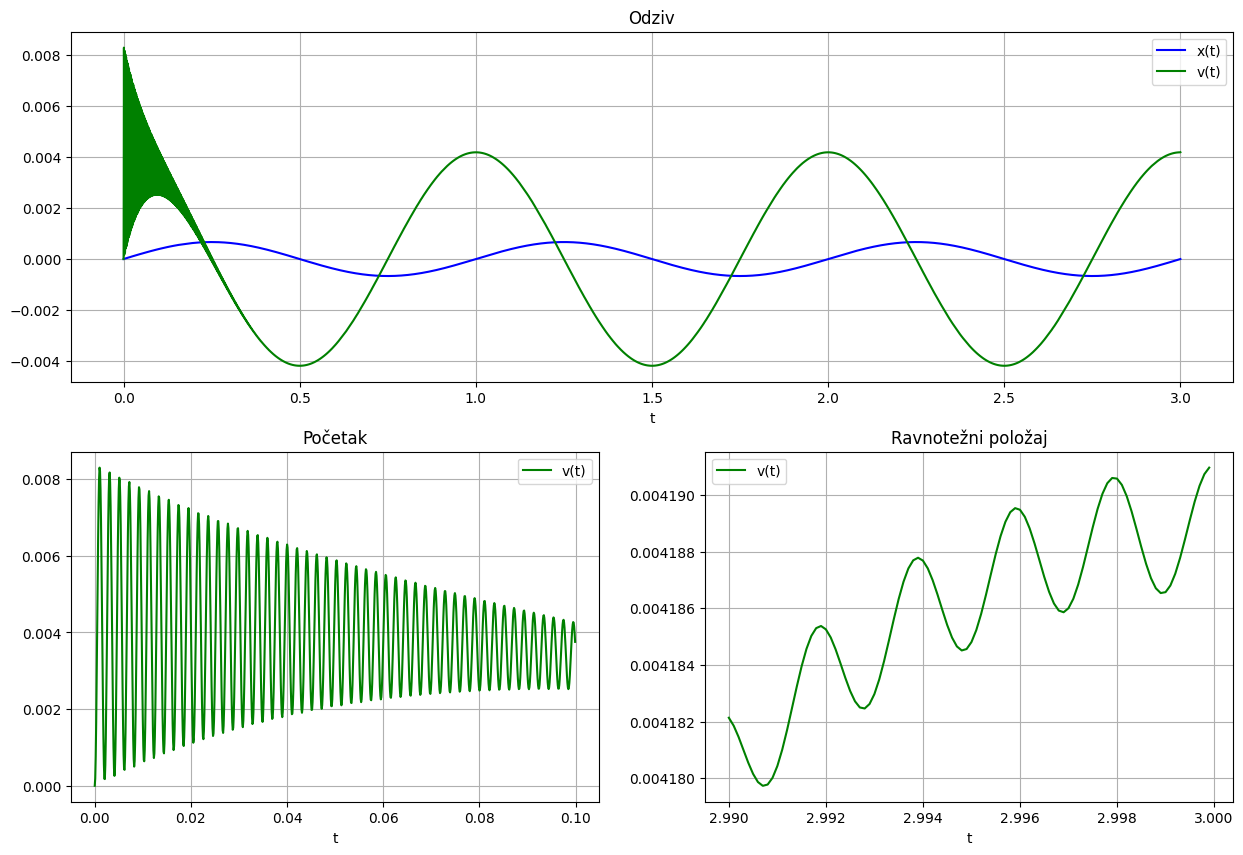

In [6]:
# Iscrtavanje grafika
plt.figure(figsize=(15,10))

plt.subplot(211)
plt.plot(t, rezultat[:, 0], 'b', label='x(t)')
plt.plot(t, rezultat[:, 1], 'g', label='v(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.title('Odziv')

# Iscrtavanje početka
plt.subplot(223)
t2 = t[t < 0.1] # koristi samo početne vremenske odbirke 
plt.plot(t2, rezultat[:len(t2), 1], 'g', label='v(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.title('Početak')

# Iscrtavanje ravnotežnog položaja
plt.subplot(224)
t3 = t[t > t[-1] - 0.01] # koristi samo krajnje vremenske odbirke, tj. samo one blizu poslednjeg vremenskog odbirka - t[-1]
plt.plot(t3, rezultat[-len(t3):, 1], 'g', label='v(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.title('Ravnotežni položaj')

plt.show()

### Zaključci:
- Primećuju se oscilacije u brzini na početku (prolazni režim)
- Tokom vremena vibracije slabe, ali nikad ne prestaju (ustaljeni režim)

Dalje se računa amplituda ove oscilacije u ravnotežnom položaju:

In [ ]:
# Računanje FFT spektra za poslednjih jednu sekundu (ustaljeni režim)
spektar = np.fft.fft(rezultat[-f_odabiranja:,1]) * T_odabiranja
freq = np.fft.fftfreq(f_odabiranja, d=T_odabiranja)

# Uzimanje samo pozitivnih frekvencija
mask = freq >= 0
freq = freq[mask]
spektar_snage = np.abs(spektar[mask])**2 * 2

# Iscrtavanje spektra
plt.figure(figsize=(15,10))
plt.semilogy(freq, spektar_snage, linewidth=4)
plt.xlabel('f [Hz]')
plt.ylabel('Spektar snage')
plt.title('Frekvencijski spektar snage brzine')
plt.grid()
plt.show()

In [ ]:
# Pronalaženje dominantnih frekvencija u spektru
sort = np.argsort(spektar_snage)[::-1]
maksimumi = [sort[0]]

# Pronalazak drugog maksimuma koji je dovoljno udaljen od prvog
for i in range(1, len(sort)):
    if np.abs(maksimumi[0] - sort[i]) > 10:
        maksimumi.append(sort[i])
        break

# Ispis rezultata
for i in range(len(maksimumi)):
    print(f'Frekvencija{i+1}={freq[maksimumi[i]]:.2f} Hz, Amplituda{i+1}={np.sqrt(spektar_snage[maksimumi[i]]):.6e}')